Dataset shape: (303, 14)
                     Accuracy  Precision    Recall        F1   ROC-AUC
Logistic Regression  0.885246   0.838710  0.928571  0.881356  0.966450
Decision Tree        0.737705   0.676471  0.821429  0.741935  0.744048
Random Forest        0.868852   0.812500  0.928571  0.866667  0.942641
SVM                  0.885246   0.838710  0.928571  0.881356  0.964286


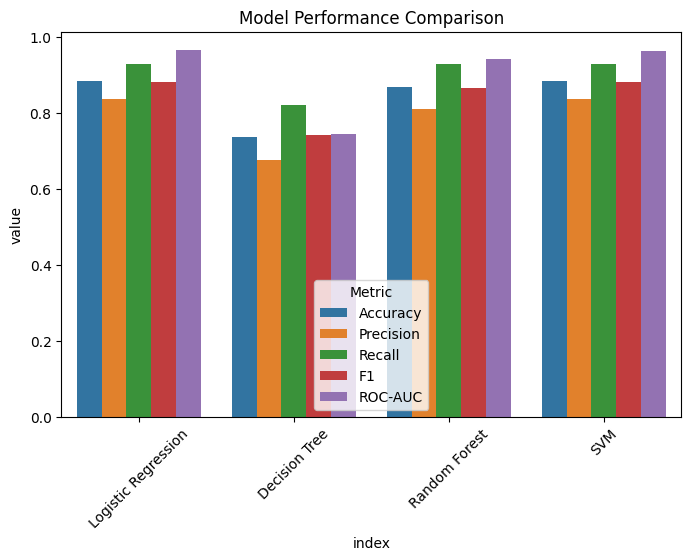


Best model: Logistic Regression
✅ Best model saved to ../models/final_model.pkl
✅ Evaluation metrics saved to ../results/evaluation_metrics.txt


In [4]:
# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import joblib

# ===============================
# 2. Load cleaned dataset
# ===============================
df = pd.read_csv("../data/heart_disease_cleaned.csv")
print("Dataset shape:", df.shape)
df.head()

# ===============================
# 3. Split features & target
# ===============================
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ===============================
# 4. Define preprocessing
# ===============================
categorical = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
numerical = ["age", "trestbps", "chol", "thalach", "oldpeak"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical)
    ]
)

# ===============================
# 5. Train models with pipeline
# ===============================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42)
}

results = {}

for name, model in models.items():
    clf = Pipeline(steps=[("preprocessor", preprocessor),
                          ("classifier", model)])
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:,1]

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

# ===============================
# 6. Compare model performance
# ===============================
results_df = pd.DataFrame(results).T
print(results_df)

plt.figure(figsize=(8,5))
sns.barplot(data=results_df.reset_index().melt(id_vars="index", var_name="Metric"),
            x="index", y="value", hue="Metric")
plt.title("Model Performance Comparison")
plt.xticks(rotation=45)
plt.show()

# ===============================
# 7. Save the best model
# ===============================
best_model_name = results_df["ROC-AUC"].idxmax()
print(f"\nBest model: {best_model_name}")

best_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", models[best_model_name])
])
best_model.fit(X_train, y_train)

joblib.dump(best_model, "../models/final_model.pkl")
print("✅ Best model saved to ../models/final_model.pkl")



# ===============================
# 8. Save evaluation metrics to results/
# ===============================
with open("../results/evaluation_metrics.txt", "w") as f:
    f.write("Heart Disease Prediction - Model Evaluation Metrics\n")
    f.write("="*60 + "\n\n")
    for model, metrics in results.items():
        f.write(f"Model: {model}\n")
        for metric, value in metrics.items():
            f.write(f"  {metric}: {value:.4f}\n")
        f.write("\n")

print("✅ Evaluation metrics saved to ../results/evaluation_metrics.txt")

